Data preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('telco_customer_churn.csv')


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['TotalCharges'].values

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [ ]:
# Convert these strings in totalcharges column to numbers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [ ]:
df['TotalCharges'].values

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
df.drop(columns=['customerID'],inplace=True) #Customer ID is a meaningless variable as far as classification is concerned.

In [ ]:
df.duplicated().sum()

22

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
for column in df.columns:
  if df[column].dtype == 'object':
    print(f'{column}: {df[column].unique()}')

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [ ]:
from sklearn.preprocessing import LabelEncoder
binary_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for column in binary_columns:
  df[column] = LabelEncoder().fit_transform(df[column])

In [ ]:
categorical_columns = df.columns[df.dtypes == 'object'].to_list()
categorical_columns

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [ ]:
for col in categorical_columns:
  freq_encoding = df[col].value_counts().to_dict()
  df[col] = df[col].map(freq_encoding)

In [ ]:
categorical_col = df.columns[df.dtypes == 'object'].to_list()
categorical_col

[]

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,680,2416,3497,2425,3094,3472,2809,2781,3875,1,2365,29.85,29.85,0
1,1,0,0,0,34,1,3385,2416,2015,3087,2418,3472,2809,2781,1472,0,1604,56.95,1889.50,0
2,1,0,0,0,2,1,3385,2416,2015,2425,3094,3472,2809,2781,3875,1,1604,53.85,108.15,1
3,1,0,0,0,45,0,680,2416,2015,3087,2418,2040,2809,2781,1472,0,1542,42.30,1840.75,0
4,0,0,0,0,2,1,3385,3096,3497,3087,3094,3472,2809,2781,3875,1,2365,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2967,2416,2015,3087,2418,2040,2703,2731,1472,1,1604,84.80,1990.50,0
7039,0,0,1,1,72,1,2967,3096,3497,2425,2418,3472,2703,2731,1472,1,1521,103.20,7362.90,0
7040,0,0,1,1,11,0,680,2416,2015,3087,3094,3472,2809,2781,3875,1,2365,29.60,346.45,0
7041,1,1,1,0,4,1,2967,3096,3497,3087,3094,3472,2809,2781,3875,1,1604,74.40,306.60,1


In [ ]:
df.duplicated().sum()

22

In [ ]:
df.shape

(7032, 20)

In [ ]:
X = df.drop(columns=['Churn'], axis=1)
y = df['Churn']

In [ ]:
X.shape

(7032, 19)

Train test split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_train.shape, x_test.shape

((5625, 19), (1407, 19))

Training a neural network

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6484 - loss: 0.6119 - val_accuracy: 0.7982 - val_loss: 0.4307
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7857 - loss: 0.4686 - val_accuracy: 0.7964 - val_loss: 0.4272
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7852 - loss: 0.4667 - val_accuracy: 0.7982 - val_loss: 0.4246
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7844 - loss: 0.4640 - val_accuracy: 0.7964 - val_loss: 0.4197
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7987 - loss: 0.4406 - val_accuracy: 0.7876 - val_loss: 0.4161
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7931 - loss: 0.4543 - val_accuracy: 0.7938 - val_loss: 0.4123
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8038 - loss: 0.4324 - val_accuracy: 0.7929 - val_loss: 0.4166
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8079 - loss: 0.4359 - val_accuracy: 0.

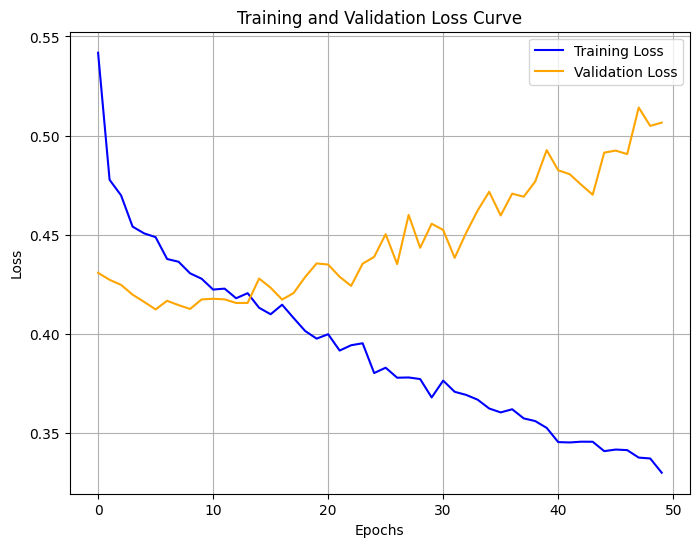

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np


# Define the NN architecture
model = Sequential()


model.add(Dense(128, input_dim=x_train.shape[1], activation='relu'))


model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='tanh'))
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(8, activation='tanh'))
model.add(Dropout(0.3))


# Output layer (binary classification: churn or no churn)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model to your training data
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Plot the training and validation loss curves
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

Confusion matrix

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


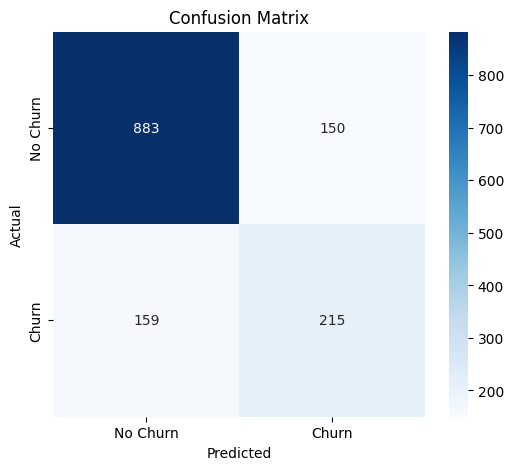

In [ ]:
# Predict on the test data (or validation data)
y_pred = (model.predict(x_test) > 0.5).astype('int32')  # Threshold at 0.5 to get binary predictions

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Classification report

In [ ]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.59      0.57      0.58       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.72      1407
weighted avg       0.78      0.78      0.78      1407



Gridsearch

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, precision_score, recall_score, accuracy_score
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.optimizers import Adam
import numpy as np

# Define model
def create_model(learning_rate, dropout_rate, units):
    model = Sequential()

    # Input layer with the correct input shape
    model.add(Dense(units, input_dim=x_train.shape[1], activation='relu'))

    # Hidden layers with Dropout for regularization
    model.add(Dense(units // 2, activation='relu'))
    model.add(Dropout(dropout_rate))

    model.add(Dense(units // 4, activation='tanh'))
    model.add(Dropout(dropout_rate))

    model.add(Dense(units // 8, activation='relu'))
    model.add(Dropout(dropout_rate))

    model.add(Dense(units // 16, activation='tanh'))
    model.add(Dropout(dropout_rate))


    model.add(Dense(1, activation='sigmoid'))

    # Compile the model with Adam optimizer
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model
# Wrap
model = KerasClassifier(
    model=create_model,
    learning_rate=0.01,
    dropout_rate=0.3,
    units=64,
    verbose=0
)

#hyperparameter grid
param_grid = {
    'learning_rate': [0.001, 0.01],
    'dropout_rate': [0.3, 0.5],
    'units': [64, 128],
    'batch_size': [16, 32],
    'epochs': [25, 50]
}

# Custom scoring
def avg_metric_score(y_true, y_pred):
    """Compute the average of accuracy, precision, and recall."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    return (acc + prec + rec) / 3

accuracy_scorer = make_scorer(accuracy_score)
precision_scorer = make_scorer(precision_score, zero_division=0)
recall_scorer = make_scorer(recall_score, zero_division=0)
avg_scorer = make_scorer(avg_metric_score)


grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring=avg_scorer  # Use average metric for model selection
)


grid_result = grid.fit(x_train, y_train)

# Display the best hyperparameters and score
print("Best Hyperparameters:", grid_result.best_params_)
print("Best Average Metric Score:", grid_result.best_score_)

# Evaluate on test data using the best model
best_model = grid_result.best_estimator_
y_test_pred = best_model.predict(x_test)


test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
avg_test_score = (test_accuracy + test_precision + test_recall) / 3

# Display the metrics
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Average Test Metric Score: {avg_test_score:.4f}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

Best Hyperparameters: {'batch_size': 32, 'dropout_rate': 0.5, 'epochs': 25, 'learning_rate': 0.01, 'units': 128}
Best Average Metric Score: 0.6762091304080435
Test Accuracy: 0.7385
Test Precision: 0.5053
Test Recall: 0.7647
Average Test Metric Score: 0.6695


Best Hyperparameters: {'batch_size': 32, 'dropout_rate': 0.5, 'epochs': 25, 'learning_rate': 0.01, 'units': 128}

Best Average Metric Score: 0.6762091304080435

Test Accuracy: 0.7385

Test Precision: 0.5053

Test Recall: 0.7647

Test F1-Score: 0.6085

Average Test Metric Score: 0.6695